# Neural Late-Fusion Pipeline für ALS-Schweregradklassifikation

## Detaillierte Architektur-Erklärung

Dieses Notebook erklärt Schritt für Schritt die Architektur unseres Deep Learning Modells zur automatischen Klassifikation von ALS-Schweregraden basierend auf Sprachaufnahmen.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Farbschema
colors = {
    'input': '#E3F2FD',
    'extractor': '#BBDEFB',
    'layers': '#90CAF9',
    'pooling': '#64B5F6',
    'processor': '#FFF3E0',
    'fusion': '#FFE0B2',
    'classifier': '#FFCCBC',
    'output': '#F8BBD9',
    'accent': '#1565C0',
    'text': '#212121',
}

def draw_box(ax, x, y, width, height, text, color, fontsize=9, bold=False):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle='round,pad=0.05,rounding_size=0.1',
        facecolor=color,
        edgecolor='#424242',
        linewidth=1.5
    )
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + width/2, y + height/2, text, 
            ha='center', va='center', fontsize=fontsize, weight=weight)

def draw_arrow(ax, start, end):
    ax.annotate('', xy=end, xytext=start,
               arrowprops=dict(arrowstyle='->', color='#37474F', lw=1.5))

---

## 1. Audio Input

### Beschreibung
Pro Patient werden **8 Audiodateien** aufgenommen:
- **5 Vokale**: A, E, I, O, U (sustained phonation)
- **3 Silbenwiederholungen**: KA, PA, TA (Diadochokinese)

Diese Aufgaben testen unterschiedliche Aspekte der Sprachproduktion, die bei ALS beeinträchtigt sein können:
- Vokale: Stimmqualität, Atemkontrolle
- Silben: Artikulationsgeschwindigkeit, motorische Koordination

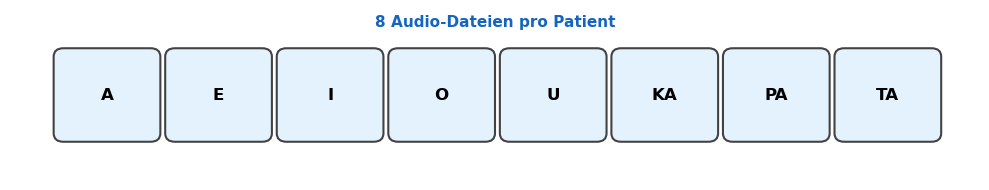

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

audio_files = ['A', 'E', 'I', 'O', 'U', 'KA', 'PA', 'TA']
for i, fname in enumerate(audio_files):
    x = 0.5 + i * 1.15
    draw_box(ax, x, 0.5, 1.0, 1.0, fname, colors['input'], fontsize=12, bold=True)

ax.text(5, 1.8, '8 Audio-Dateien pro Patient', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 2. Feature Extraction mit Wav2Vec 2.0

### Beschreibung
Wir verwenden **Wav2Vec 2.0 Large** (`facebook/wav2vec2-large-960h`), ein vortrainiertes Self-Supervised Learning Modell.

### Warum Wav2Vec 2.0?
- Lernt robuste Sprachrepräsentationen aus rohem Audio
- Vortrainiert auf 960 Stunden Librispeech
- Erfasst sowohl akustische als auch linguistische Merkmale

### Architektur
- **CNN Encoder**: Konvertiert Wellenform zu latenten Repräsentationen
- **Transformer**: 24 Schichten mit Self-Attention
- **Hidden Size**: 1024 Dimensionen pro Layer

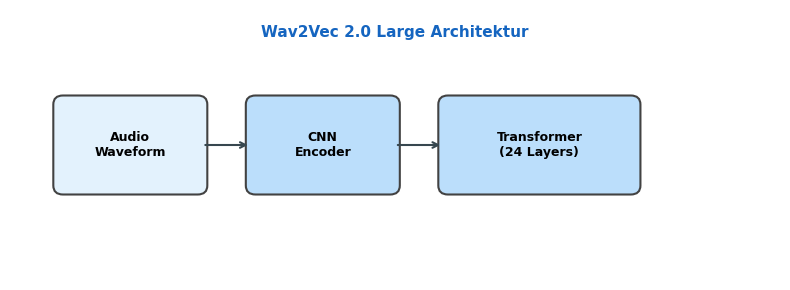

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.set_xlim(0, 8)
ax.set_ylim(0, 3)
ax.axis('off')

# Audio Input
draw_box(ax, 0.5, 1.0, 1.5, 1.0, 'Audio\nWaveform', colors['input'], fontsize=9, bold=True)

# CNN
draw_box(ax, 2.5, 1.0, 1.5, 1.0, 'CNN\nEncoder', colors['extractor'], fontsize=9, bold=True)

# Transformer
draw_box(ax, 4.5, 1.0, 2.0, 1.0, 'Transformer\n(24 Layers)', colors['extractor'], fontsize=9, bold=True)

# Arrows
draw_arrow(ax, (2.0, 1.5), (2.5, 1.5))
draw_arrow(ax, (4.0, 1.5), (4.5, 1.5))

ax.text(4, 2.7, 'Wav2Vec 2.0 Large Architektur', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 3. Multi-Layer Feature Extraction

### Beschreibung
Anstatt nur die letzte Schicht zu verwenden, extrahieren wir Features aus **5 verschiedenen Transformer-Layern**: 6, 9, 12, 15, 18.

### Warum Multi-Layer?
Verschiedene Layer kodieren unterschiedliche Informationen:
- **Frühe Layer (6, 9)**: Akustische Merkmale (Tonhöhe, Formanten)
- **Mittlere Layer (12)**: Phonetische Merkmale
- **Späte Layer (15, 18)**: Linguistische/semantische Merkmale

Für ALS-Erkennung sind besonders die akustischen Merkmale wichtig!

### Layer Fusion
Die Features aller Layer werden **konkateniert**:
- 5 Layer × 1024 Dimensionen = **5120 Dimensionen**

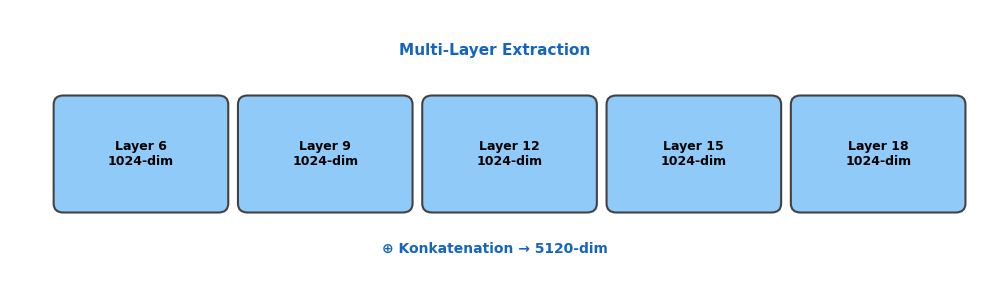

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

layers = [6, 9, 12, 15, 18]
for i, layer_num in enumerate(layers):
    x = 0.5 + i * 1.9
    draw_box(ax, x, 0.8, 1.7, 1.2, f'Layer {layer_num}\n1024-dim', colors['layers'], fontsize=9, bold=True)

# Concat symbol
ax.text(5, 0.3, '⊕ Konkatenation → 5120-dim', ha='center', fontsize=10, weight='bold', color=colors['accent'])
ax.text(5, 2.5, 'Multi-Layer Extraction', ha='center', fontsize=11, weight='bold', color=colors['accent'])

plt.tight_layout()
plt.show()

---

## 4. Temporal Pooling

### Beschreibung
Audiodateien haben unterschiedliche Längen, daher müssen wir die variable Zeitdimension zu einem fixen Vektor aggregieren.

### Mean Pooling
Wir verwenden **Mean Pooling** über die Zeitachse:
- Eingabe: (Batch, Zeit, 5120)
- Ausgabe: (Batch, 5120)

### Ergebnis
Nach dem Pooling haben wir **8 Vektoren à 5120 Dimensionen** – einen pro Audiodatei.

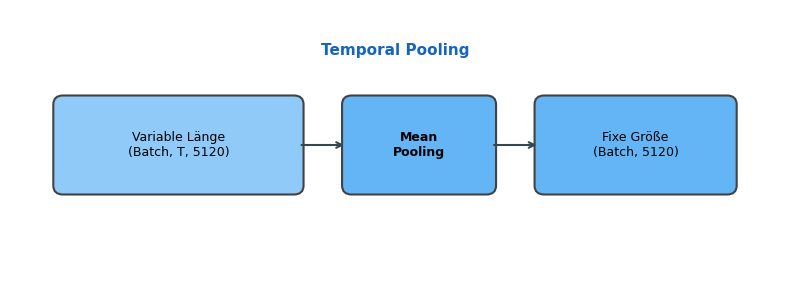

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.set_xlim(0, 8)
ax.set_ylim(0, 3)
ax.axis('off')

# Variable length input
draw_box(ax, 0.5, 1.0, 2.5, 1.0, 'Variable Länge\n(Batch, T, 5120)', colors['layers'], fontsize=9)

# Mean pooling
draw_box(ax, 3.5, 1.0, 1.5, 1.0, 'Mean\nPooling', colors['pooling'], fontsize=9, bold=True)

# Fixed output
draw_box(ax, 5.5, 1.0, 2.0, 1.0, 'Fixe Größe\n(Batch, 5120)', colors['pooling'], fontsize=9)

# Arrows
draw_arrow(ax, (3.0, 1.5), (3.5, 1.5))
draw_arrow(ax, (5.0, 1.5), (5.5, 1.5))

ax.text(4, 2.5, 'Temporal Pooling', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 5. File Processors

### Beschreibung
Jede der 8 Audiodateien wird durch einen eigenen **File Processor** verarbeitet. Da `shared_file_processor=False`, lernt jeder Prozessor separate Parameter.

### Architektur eines File Processors
```
Linear(5120 → 256) → LayerNorm → ReLU → Dropout(0.3)
Linear(256 → 128)  → LayerNorm → ReLU → Dropout(0.3)
```

### Warum separate Prozessoren?
- Vokale und Silben haben unterschiedliche akustische Eigenschaften
- Das Modell kann spezifische Muster für jede Aufgabe lernen
- Mehr Flexibilität, aber auch mehr Parameter

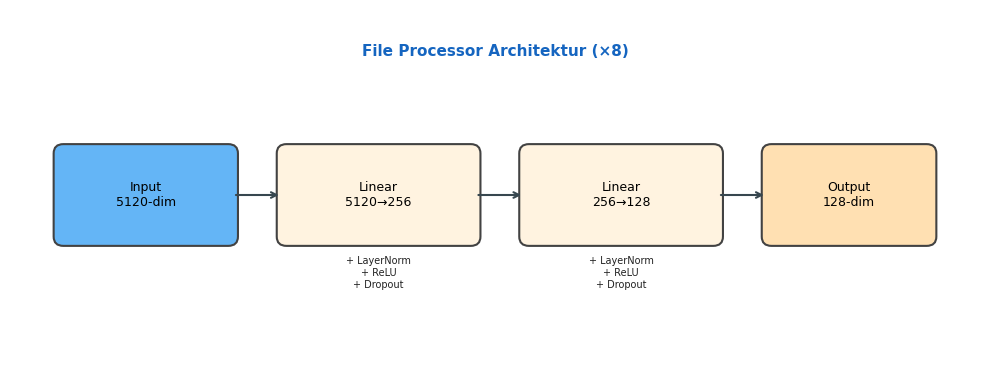

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# Input
draw_box(ax, 0.5, 1.5, 1.8, 1.0, 'Input\n5120-dim', colors['pooling'], fontsize=9)

# First layer
draw_box(ax, 2.8, 1.5, 2.0, 1.0, 'Linear\n5120→256', colors['processor'], fontsize=9)

# Second layer
draw_box(ax, 5.3, 1.5, 2.0, 1.0, 'Linear\n256→128', colors['processor'], fontsize=9)

# Output
draw_box(ax, 7.8, 1.5, 1.7, 1.0, 'Output\n128-dim', colors['fusion'], fontsize=9)

# Arrows
draw_arrow(ax, (2.3, 2.0), (2.8, 2.0))
draw_arrow(ax, (4.8, 2.0), (5.3, 2.0))
draw_arrow(ax, (7.3, 2.0), (7.8, 2.0))

# Annotations
ax.text(3.8, 1.0, '+ LayerNorm\n+ ReLU\n+ Dropout', ha='center', fontsize=7, color=colors['text'])
ax.text(6.3, 1.0, '+ LayerNorm\n+ ReLU\n+ Dropout', ha='center', fontsize=7, color=colors['text'])

ax.text(5, 3.5, 'File Processor Architektur (×8)', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 6. Late Fusion

### Beschreibung
Die **Late Fusion** kombiniert die verarbeiteten Features aller 8 Dateien. Wir verwenden **Feature-Level Fusion** mit Konkatenation.

### Berechnung
- 8 Dateien × 128 Dimensionen = **1024 Dimensionen**

### Warum Late Fusion?
- Erhält datei-spezifische Informationen bis zur Fusion
- Ermöglicht dem Klassifikator, Beziehungen zwischen Dateien zu lernen
- Flexibler als Early Fusion (Feature-Konkatenation vor Verarbeitung)

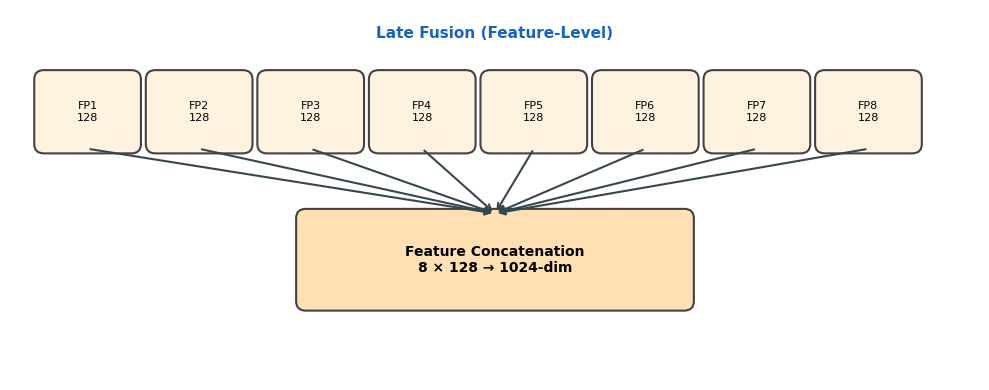

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# 8 input vectors
for i in range(8):
    x = 0.3 + i * 1.15
    draw_box(ax, x, 2.5, 1.0, 0.8, f'FP{i+1}\n128', colors['processor'], fontsize=8)
    draw_arrow(ax, (x + 0.5, 2.5), (5, 1.8))

# Fusion box
draw_box(ax, 3.0, 0.8, 4.0, 1.0, 'Feature Concatenation\n8 × 128 → 1024-dim', colors['fusion'], fontsize=10, bold=True)

ax.text(5, 3.7, 'Late Fusion (Feature-Level)', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 7. Klassifikator

### Beschreibung
Der finale Klassifikator ist ein **Multi-Layer Perceptron (MLP)**, das den fusionierten Vektor auf 5 Klassen abbildet.

### Architektur
```
Linear(1024 → 256) → LayerNorm → ReLU → Dropout(0.3)
Linear(256 → 5)
```

### Output
- 5 Logits für die 5 ALS-Schweregrade (Klasse 0-4)
- Softmax für Wahrscheinlichkeitsverteilung

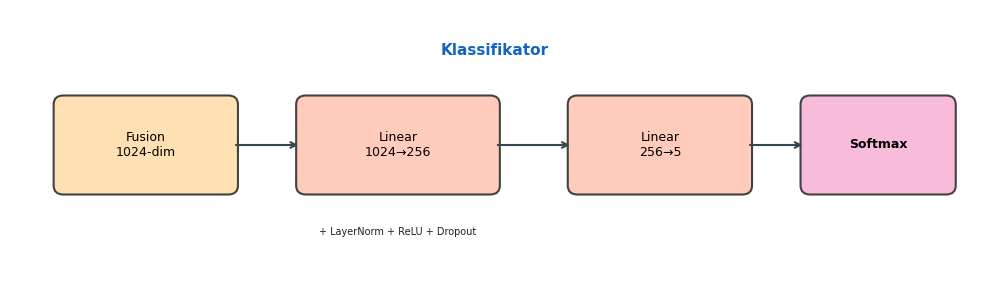

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

# Input
draw_box(ax, 0.5, 1.0, 1.8, 1.0, 'Fusion\n1024-dim', colors['fusion'], fontsize=9)

# Hidden layer
draw_box(ax, 3.0, 1.0, 2.0, 1.0, 'Linear\n1024→256', colors['classifier'], fontsize=9)

# Output layer
draw_box(ax, 5.8, 1.0, 1.8, 1.0, 'Linear\n256→5', colors['classifier'], fontsize=9)

# Softmax
draw_box(ax, 8.2, 1.0, 1.5, 1.0, 'Softmax', colors['output'], fontsize=9, bold=True)

# Arrows
draw_arrow(ax, (2.3, 1.5), (3.0, 1.5))
draw_arrow(ax, (5.0, 1.5), (5.8, 1.5))
draw_arrow(ax, (7.6, 1.5), (8.2, 1.5))

ax.text(4.0, 0.5, '+ LayerNorm + ReLU + Dropout', ha='center', fontsize=7, color=colors['text'])
ax.text(5, 2.5, 'Klassifikator', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## 8. Output: 5 ALS-Schweregrade

### Klassen
Das Modell klassifiziert in **5 Schweregrade** (0-4):
- **Klasse 0**: Keine oder minimale Beeinträchtigung
- **Klasse 1**: Leichte Beeinträchtigung
- **Klasse 2**: Moderate Beeinträchtigung
- **Klasse 3**: Schwere Beeinträchtigung
- **Klasse 4**: Sehr schwere Beeinträchtigung

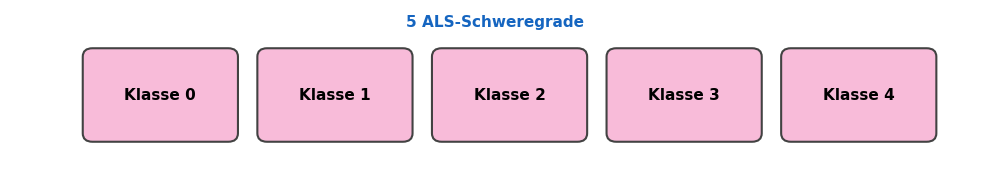

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

for i in range(5):
    x = 0.8 + i * 1.8
    draw_box(ax, x, 0.5, 1.5, 1.0, f'Klasse {i}', colors['output'], fontsize=11, bold=True)

ax.text(5, 1.8, '5 ALS-Schweregrade', ha='center', fontsize=11, weight='bold', color=colors['accent'])
plt.tight_layout()
plt.show()

---

## Training Konfiguration

### Hyperparameter
| Parameter | Wert |
|-----------|------|
| Epochs | 40 |
| Batch Size | 24 |
| Learning Rate | 0.0005 |
| Weight Decay | 0.0001 |
| Dropout | 0.3 |
| Early Stopping | 10 Epochs |

### Loss Function
**Class-weighted CrossEntropy Loss** um Klassenimbalance auszugleichen.

### Optimizer
**AdamW** mit Gradient Clipping (max_grad_norm=1.0)

### Ergebnisse
- **Best Epoch**: 28
- **Best F1-Macro**: 0.594
- **Validation Accuracy**: 69.8%

---

## Zusammenfassung: Komplette Pipeline

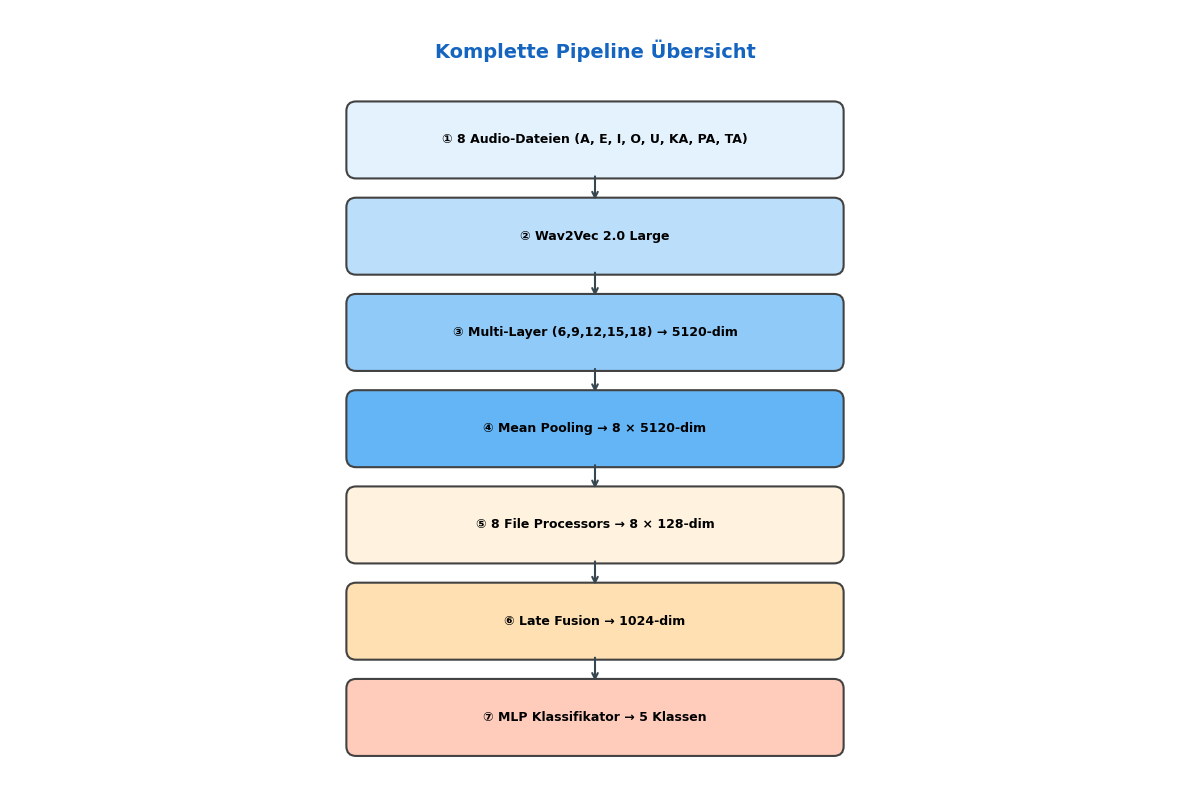

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')

center_x = 6.0

# Title
ax.text(center_x, 7.5, 'Komplette Pipeline Übersicht', ha='center', fontsize=14, weight='bold', color=colors['accent'])

# 1. Input
draw_box(ax, 3.5, 6.3, 5.0, 0.7, '① 8 Audio-Dateien (A, E, I, O, U, KA, PA, TA)', colors['input'], fontsize=9, bold=True)

# 2. Extractor
draw_box(ax, 3.5, 5.3, 5.0, 0.7, '② Wav2Vec 2.0 Large', colors['extractor'], fontsize=9, bold=True)

# 3. Layers
draw_box(ax, 3.5, 4.3, 5.0, 0.7, '③ Multi-Layer (6,9,12,15,18) → 5120-dim', colors['layers'], fontsize=9, bold=True)

# 4. Pooling
draw_box(ax, 3.5, 3.3, 5.0, 0.7, '④ Mean Pooling → 8 × 5120-dim', colors['pooling'], fontsize=9, bold=True)

# 5. Processors
draw_box(ax, 3.5, 2.3, 5.0, 0.7, '⑤ 8 File Processors → 8 × 128-dim', colors['processor'], fontsize=9, bold=True)

# 6. Fusion
draw_box(ax, 3.5, 1.3, 5.0, 0.7, '⑥ Late Fusion → 1024-dim', colors['fusion'], fontsize=9, bold=True)

# 7. Classifier
draw_box(ax, 3.5, 0.3, 5.0, 0.7, '⑦ MLP Klassifikator → 5 Klassen', colors['classifier'], fontsize=9, bold=True)

# Arrows
for y in [6.3, 5.3, 4.3, 3.3, 2.3, 1.3]:
    draw_arrow(ax, (center_x, y), (center_x, y - 0.3))

plt.tight_layout()
plt.show()

---

## Key Takeaways

1. **Multi-Layer Extraction** ist entscheidend für die Performance – frühe Layer erfassen akustische Merkmale, die bei ALS wichtig sind

2. **Late Fusion** ermöglicht es dem Modell, datei-spezifische Muster zu lernen und diese intelligent zu kombinieren

3. **Separate File Processors** bieten mehr Flexibilität als geteilte Gewichte

4. **Class-weighted Loss** ist wichtig bei unbalancierten Klassen

5. Mit einem F1-Macro von **0.594** nähern wir uns dem Challenge-Target von **≥0.6**